# F1 Race Result Factor Analysis

This notebook shows the main outputs from the current project run and summarizes how qualifying position and selected race-context factors relate to race finishing position.

In [1]:
import sys
from pathlib import Path
import contextlib
import io
import logging

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.append(str(SRC_DIR))

import pandas as pd
from IPython.display import Image, display

from config import DATA_DIR, RESULTS_DIR
from process import finalize_results
from analyze import (
    average_finish_by_grid,
    compute_correlation,
    plot_statistics,
    plot_individual_feature_charts,
    plot_feature_analysis,
    plot_strategy_scenarios,
    pole_to_win_rate,
    run_linear_regression,
    run_feature_model_comparison,
    run_strategy_scenarios,
    save_feature_analysis_outputs,
    save_strategy_scenarios,
    save_summary_table,
)
from diagnostics import regression_diagnostics
from main import analyze_source, load_source


## Load merged race data

The merged dataset contains one row per driver-race observation. Qualifying position is the baseline predictor, and the combined run can add race-context factors such as pit stops, rainfall, track temperature, and circuit type.

In [2]:
source_name = "combined"
RUN_PIPELINE_IN_NOTEBOOK = False
merged_data_path = DATA_DIR / "merged_results.csv"

if merged_data_path.exists():
    df = finalize_results(pd.read_csv(merged_data_path))
    print("Loaded generated data from:", merged_data_path)
elif RUN_PIPELINE_IN_NOTEBOOK:
    DATA_DIR.mkdir(parents=True, exist_ok=True)
    RESULTS_DIR.mkdir(parents=True, exist_ok=True)
    logging.getLogger().setLevel(logging.WARNING)
    pipeline_log = io.StringIO()
    with contextlib.redirect_stdout(pipeline_log), contextlib.redirect_stderr(pipeline_log):
        df = load_source(source_name)
        if df.empty:
            raise RuntimeError("No data loaded. Check internet access for OpenF1/FastF1 or run another source from src/main.py.")
        analyze_source(source_name, df, merged_data_path, RESULTS_DIR)
    print("Pipeline completed for source:", source_name)
else:
    raise FileNotFoundError(
        "Generated data was not found. Run `python src/main.py --source combined` "
        "from the project root first, then rerun this notebook. "
        "To reproduce from inside the notebook instead, set RUN_PIPELINE_IN_NOTEBOOK = True."
    )

print("Dataset shape:", df.shape)
df.head()


Loaded generated data from: /Users/seeso_rui/dsci510/f1-qualifying-prediction/data/merged_results.csv
Dataset shape: (1208, 12)


,driver_number,qualifying_position,race_position,pit_stop_count,rainfall,track_temperature,circuit_type,full_name,name_acronym,year,circuit,meeting_key
0,1,1,1,0,0,31.011801,permanent,Max VERSTAPPEN,VER,2023,Sakhir,1141
1,11,2,2,0,0,31.011801,permanent,Sergio PEREZ,PER,2023,Sakhir,1141
2,55,4,4,0,0,31.011801,permanent,Carlos SAINZ,SAI,2023,Sakhir,1141
3,14,5,3,0,0,31.011801,permanent,Fernando ALONSO,ALO,2023,Sakhir,1141
4,63,6,7,0,0,31.011801,permanent,George RUSSELL,RUS,2023,Sakhir,1141


## Recompute summary outputs

This step recalculates the main statistics used in the written report: correlation, regression metrics, and average finishing position by grid slot.

In [3]:
avg_df = average_finish_by_grid(df)
corr = compute_correlation(df)
regression_results = run_linear_regression(df)
summary_df = save_summary_table(df, avg_df, corr, regression_results, RESULTS_DIR)
summary_df.head(15)

Pearson correlation: 0.7497
Linear regression: race_pos = 0.6877 * qual_pos + 2.4485
R-squared: 0.5621, MAE: 2.6405, RMSE: 3.4669, CV MAE: 2.6484, CV RMSE: 3.4778


,section,metric,value,qualifying_position,num_races
0,overall,number_of_races,69.0000,NaN,NaN
1,overall,number_of_driver_race_observations,1208.0000,NaN,NaN
2,overall,mean_qualifying_position,10.1018,NaN,NaN
3,overall,mean_finishing_position,9.3957,NaN,NaN
4,overall,correlation_qualifying_vs_finishing,0.7497,NaN,NaN
5,overall,regression_coefficient,0.6877,NaN,NaN
6,overall,regression_intercept,2.4485,NaN,NaN
7,overall,r_squared,0.5621,NaN,NaN
8,overall,mae,2.6405,NaN,NaN
9,overall,rmse,3.4669,NaN,NaN


## Regression assumption diagnostics

This section checks whether the simple linear regression model is appropriate for the data. The diagnostics focus on linearity, independence, homoscedasticity, and residual normality.


In [4]:
diagnostics_df = regression_diagnostics(df, RESULTS_DIR)
diagnostics_df


,check,method,statistic,p_value,interpretation
0,linearity,residuals_vs_fitted_plot,NaN,NaN,Inspect whether residuals are centered around ...
1,independence,durbin_watson,1.9821,NaN,Values near 2 suggest weak serial correlation;...
2,homoscedasticity,breusch_pagan,5.5336,0.0187,Small p-values suggest non-constant residual v...
3,normality,shapiro_wilk,0.9745,0.0000,Small p-values suggest residuals deviate from ...


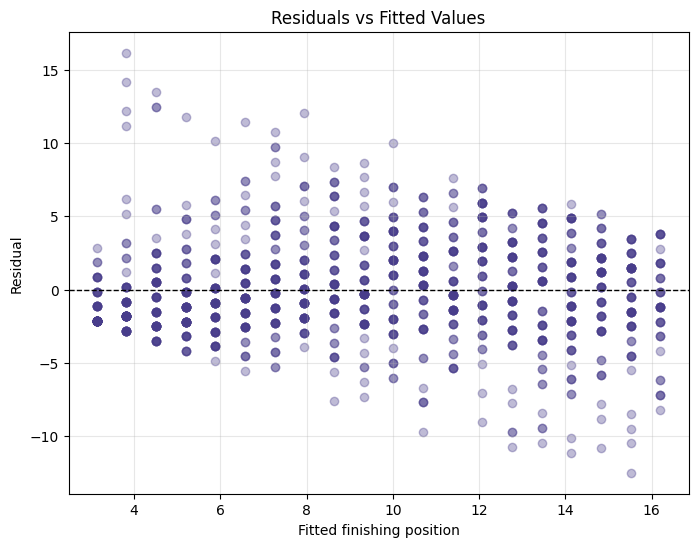

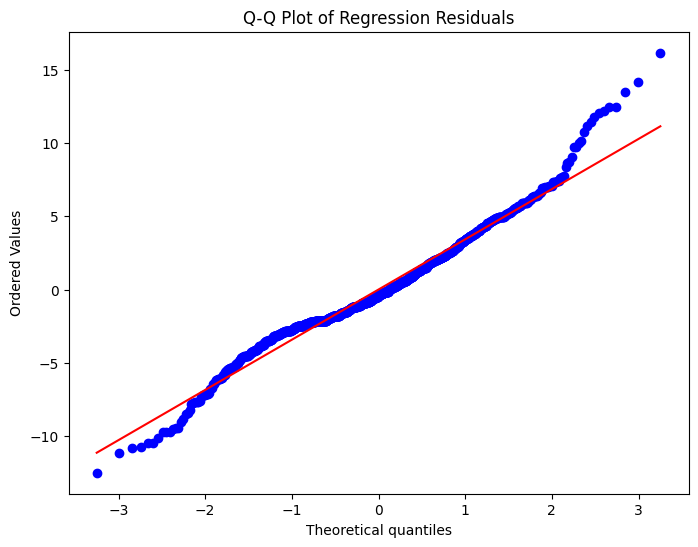

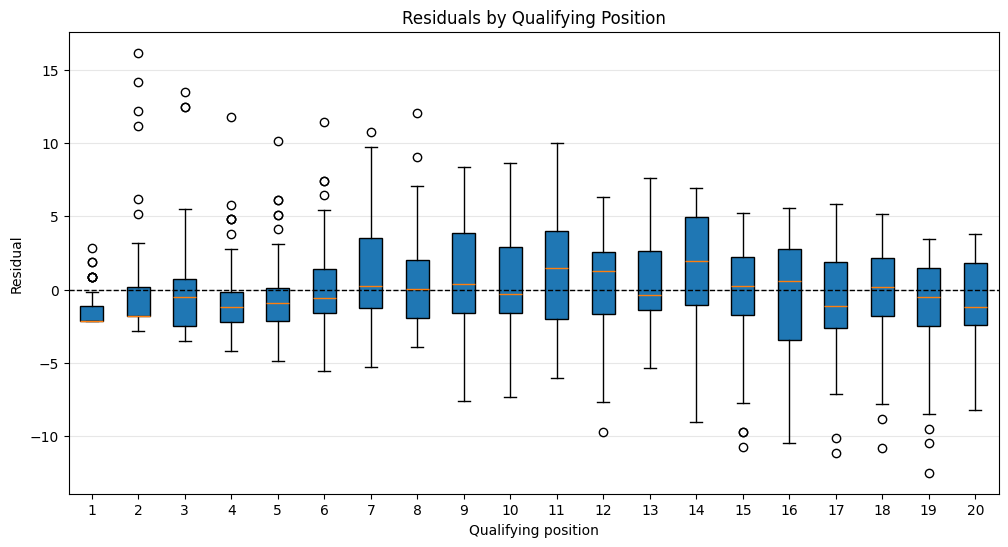

In [5]:
for filename in [
    "F1_Residuals_vs_Fitted.png",
    "F1_QQ_Plot.png",
    "F1_Residuals_by_Grid.png",
]:
    display(Image(filename=f"{RESULTS_DIR}/{filename}"))


## Regenerate charts

The project saves chart files into the `results/` folder so they can be reused in the report and reviewed without rerunning the full API pipeline.

In [6]:
plot_statistics(df, avg_df, corr, regression_results, RESULTS_DIR)

## Correlation visualization

This scatter plot shows the baseline relationship between qualifying position and finishing position. The upward regression line and positive correlation indicate that starting farther back is generally associated with finishing farther back, although race-context factors still create substantial variation.

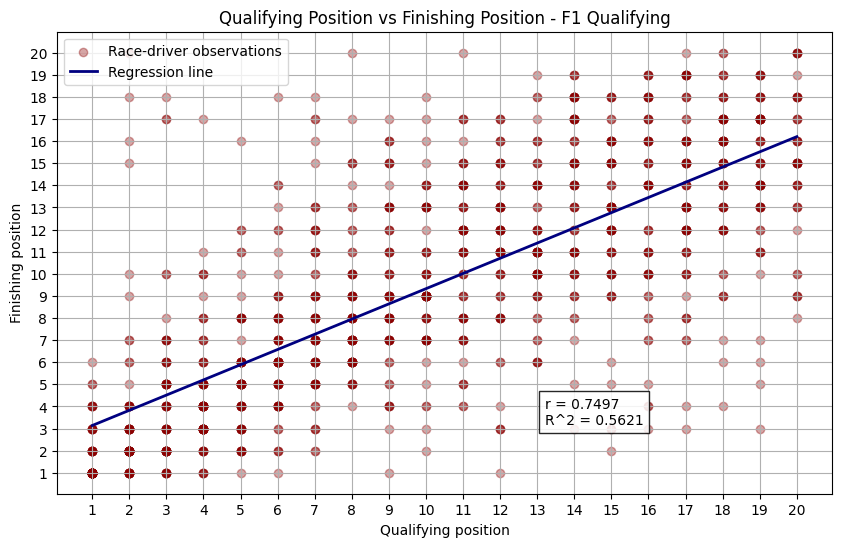

In [7]:
display(Image(filename=f"{RESULTS_DIR}/F1_Qualifying_scatterplot.png"))

## Average finishing position by grid position

This line chart summarizes the average finishing position for each grid slot. The pattern rises steadily, which supports using qualifying position as the baseline predictor before adding other race-context factors.

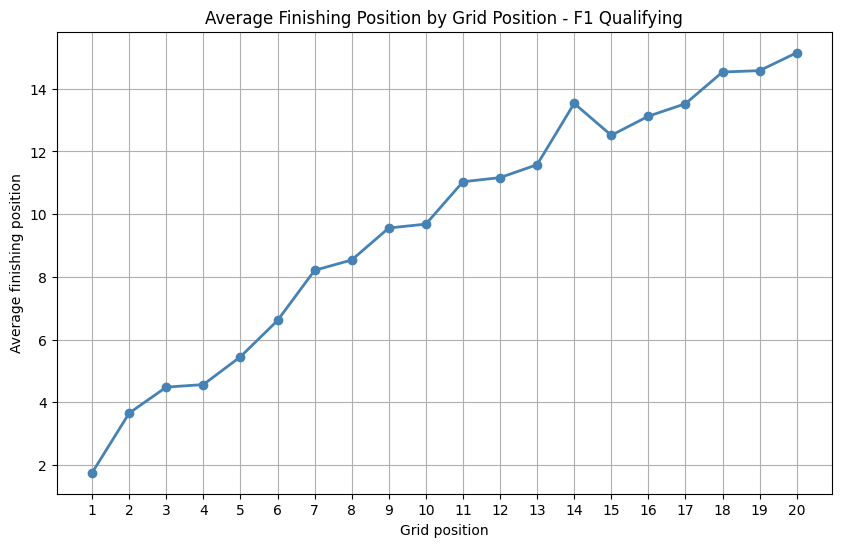

In [8]:
display(Image(filename=f"{RESULTS_DIR}/F1_Qualifying_linechart.png"))

## Pole position conversion to wins

This bar chart compares win rates for the first three grid positions. Pole position clearly has the strongest conversion rate, which matches the project question about how much starting order matters.

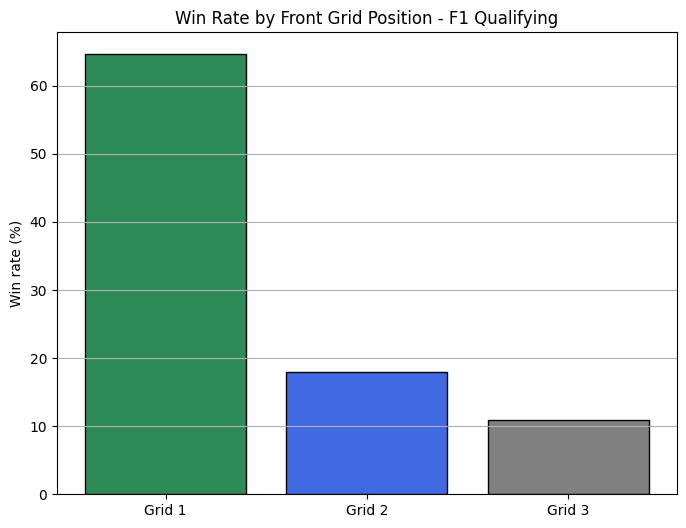

In [9]:
display(Image(filename=f"{RESULTS_DIR}/F1_Pole_to_Win_barchart.png"))

## Prediction performance

This predicted-versus-actual plot shows how the regression model performs across the full range of finishing positions. Points close to the diagonal line indicate more accurate predictions.

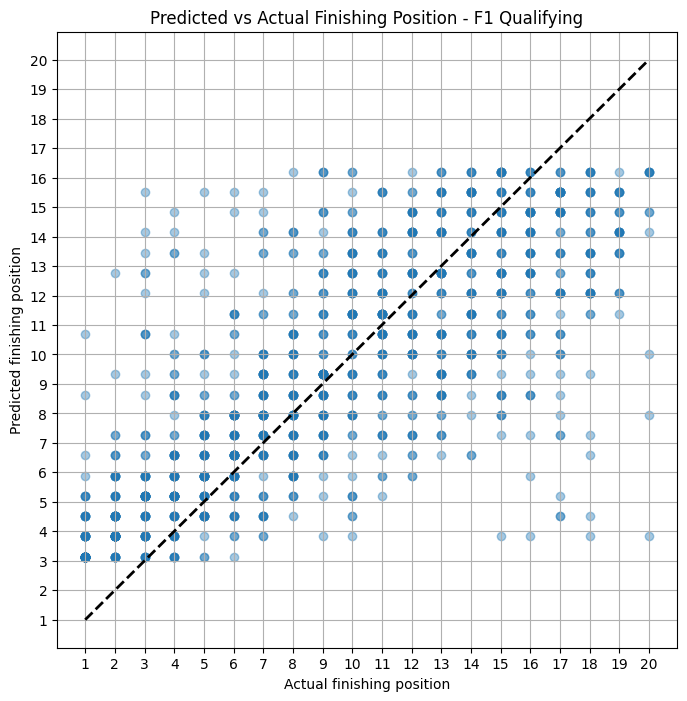

In [10]:
display(Image(filename=f"{RESULTS_DIR}/F1_Predicted_vs_Actual_scatterplot.png"))

## Variability by grid position

The boxplot adds uncertainty information that is not visible in averages alone. Even though front-grid starters usually finish better, the spread shows that race incidents, strategy, and overtaking still matter.

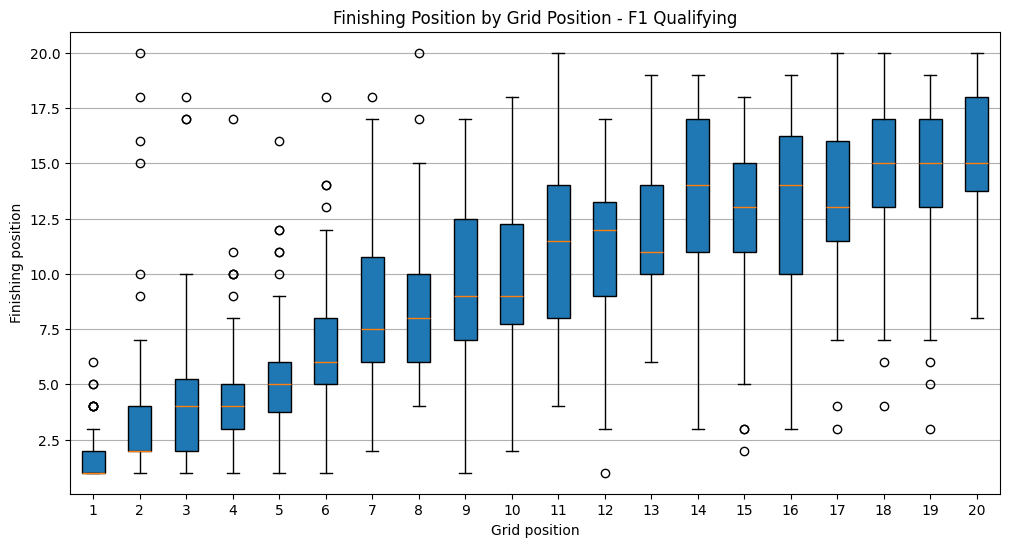

In [11]:
display(Image(filename=f"{RESULTS_DIR}/F1_Finishing_Position_boxplot.png"))

## Stage 1: Individual feature analysis

This section tests each available feature independently. The modeling table combines three sources: OpenF1 provides qualifying position, finishing position, and pit stop count; FastF1 provides race weather features; and Kaggle/Ergast race metadata provides circuit type.


In [12]:
feature_comparison, feature_results = run_feature_model_comparison(df)
save_feature_analysis_outputs(feature_comparison, feature_results, RESULTS_DIR)
plot_individual_feature_charts(df, RESULTS_DIR)
feature_comparison


Qualifying only: R-squared=0.5621, MAE=2.6405, RMSE=3.4669, CV MAE=2.6532, CV RMSE=3.4824
Pit stops only: R-squared=0.0028, MAE=4.4977, RMSE=5.2317, CV MAE=4.5016, CV RMSE=5.2388
Weather only: R-squared=0.0002, MAE=4.5071, RMSE=5.2386, CV MAE=4.5157, CV RMSE=5.2538
Circuit type only: R-squared=0.0003, MAE=4.5072, RMSE=5.2382, CV MAE=4.5156, CV RMSE=5.2493
Combined: R-squared=0.5636, MAE=2.6346, RMSE=3.4609, CV MAE=2.6535, CV RMSE=3.4860


,model,features,n_observations,mae,rmse,r_squared,cv_mae,cv_rmse
0,Qualifying only,qualifying_position,1208,2.6405,3.4669,0.5621,2.6532,3.4824
1,Pit stops only,pit_stop_count,1208,4.4977,5.2317,0.0028,4.5016,5.2388
2,Weather only,"rainfall, track_temperature",1208,4.5071,5.2386,0.0002,4.5157,5.2538
3,Circuit type only,circuit_type,1208,4.5072,5.2382,0.0003,4.5156,5.2493
4,Combined,"qualifying_position, pit_stop_count, circuit_t...",1208,2.6346,3.4609,0.5636,2.6535,3.4860


## Stage 2: Combined feature model

The final model combines qualifying position with the available race-context features and compares it against the qualifying-only baseline using MAE, RMSE, R-squared, and cross-validation metrics.


In [13]:
plot_feature_analysis(df, feature_comparison, feature_results, RESULTS_DIR)
feature_comparison


,model,features,n_observations,mae,rmse,r_squared,cv_mae,cv_rmse
0,Qualifying only,qualifying_position,1208,2.6405,3.4669,0.5621,2.6532,3.4824
1,Pit stops only,pit_stop_count,1208,4.4977,5.2317,0.0028,4.5016,5.2388
2,Weather only,"rainfall, track_temperature",1208,4.5071,5.2386,0.0002,4.5157,5.2538
3,Circuit type only,circuit_type,1208,4.5072,5.2382,0.0003,4.5156,5.2493
4,Combined,"qualifying_position, pit_stop_count, circuit_t...",1208,2.6346,3.4609,0.5636,2.6535,3.4860


## Combined model diagnostics

These charts summarize the multivariable analysis: feature correlations, final-model coefficient importance, and actual-versus-predicted finishing position.


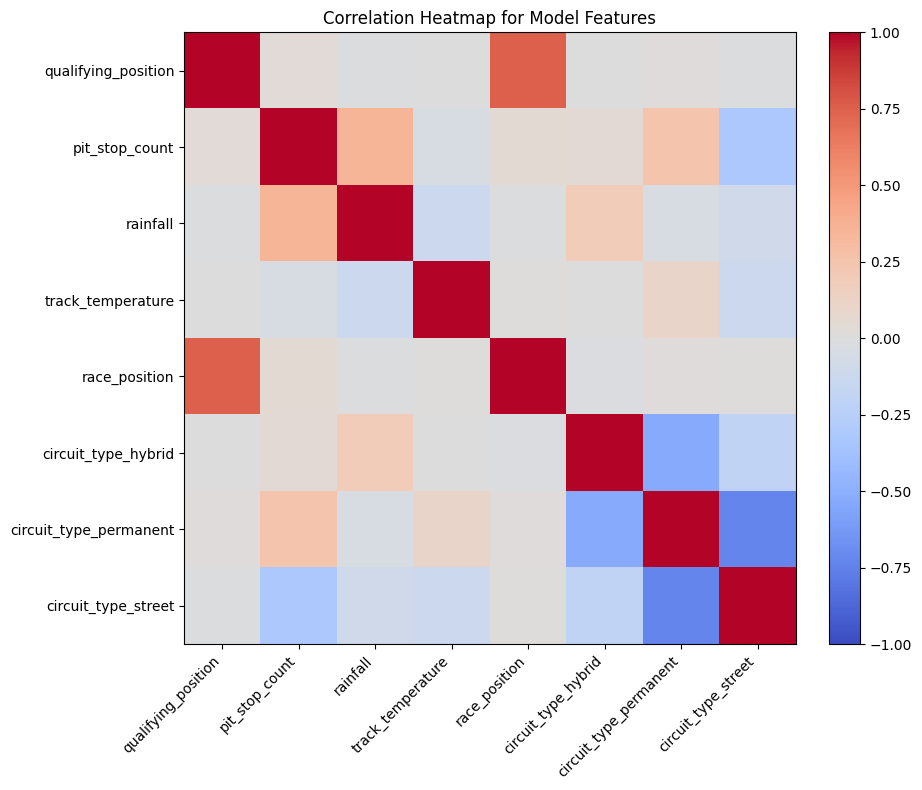

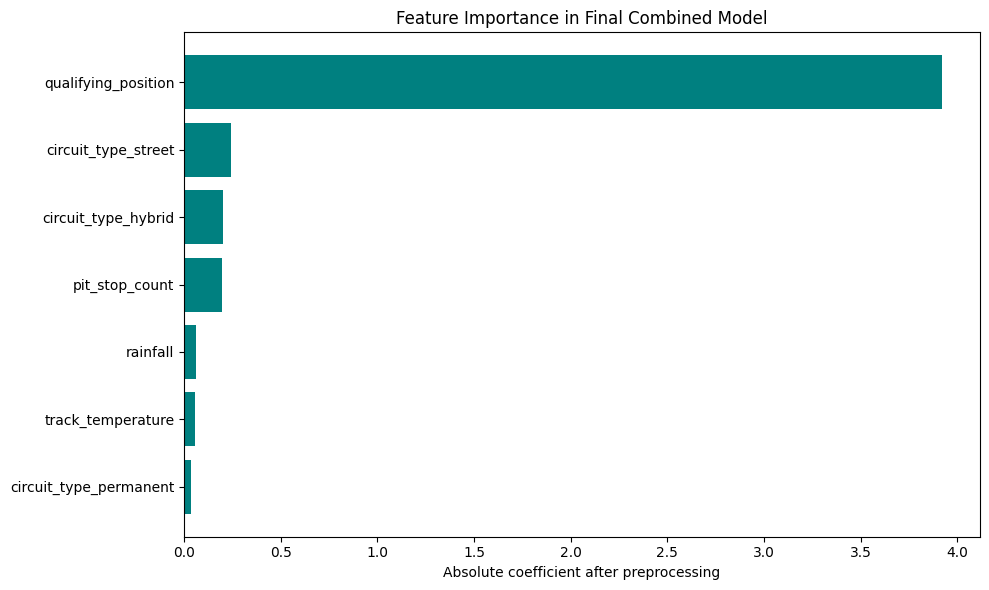

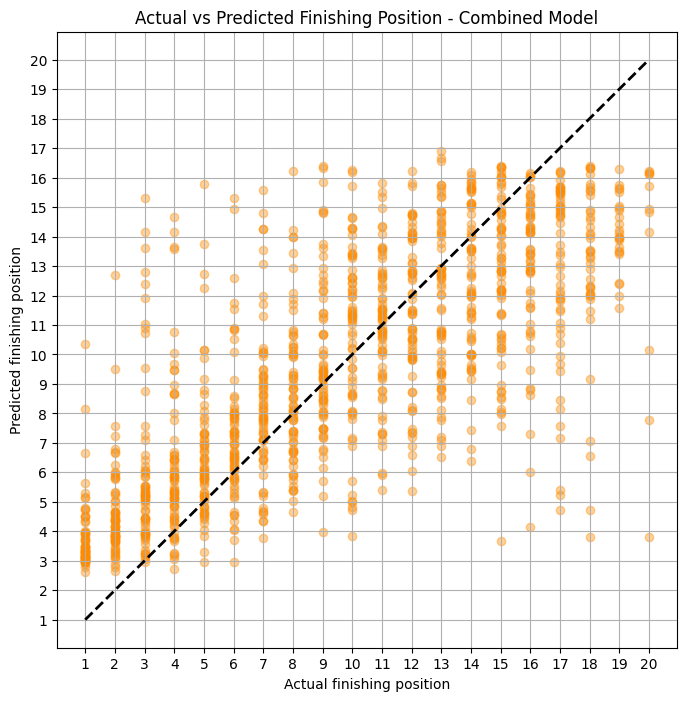

In [14]:
for filename in [
    "F1_Feature_Correlation_Heatmap.png",
    "F1_Feature_Importance.png",
    "F1_Combined_Actual_vs_Predicted.png",
]:
    display(Image(filename=f"{RESULTS_DIR}/{filename}"))


## Strategy simulation extension

This optional extension does not use actual post-race tire choices as model predictors. Instead, it uses tire-compound sequences only as scenario labels and changes model inputs such as pit stop count, rain conditions, track temperature, and circuit type to estimate how the combined model would respond under different race contexts.


In [15]:
strategy_scenarios = run_strategy_scenarios(df)
save_strategy_scenarios(strategy_scenarios, RESULTS_DIR)
plot_strategy_scenarios(strategy_scenarios, RESULTS_DIR)
strategy_scenarios


,scenario,tire_strategy_assumption,qualifying_position,pit_stop_count,circuit_type,rainfall,track_temperature,predicted_finish_position
0,"P2 dry race, one stop",Medium-Hard,2,1,permanent,0,35.816883,3.69
1,"P2 dry race, two stops",Medium-Hard-Soft,2,2,permanent,0,35.816883,3.87
2,"P10 dry race, one stop",Hard-Medium,10,1,permanent,0,35.816883,9.18
3,"P10 wet race, two stops",Intermediate-Medium-Hard,10,2,permanent,1,35.816883,9.21
4,"P5 street circuit, one stop",Medium-Hard,5,1,street,0,35.816883,6.03
5,"P5 street circuit, three stops",Soft-Medium-Hard-Soft,5,3,street,0,35.816883,6.38
6,"P6 wet hybrid circuit, two stops",Intermediate-Medium-Hard,6,2,hybrid,1,35.816883,6.30
7,"P6 wet hybrid circuit, three stops",Wet-Intermediate-Medium-Hard,6,3,hybrid,1,35.816883,6.48


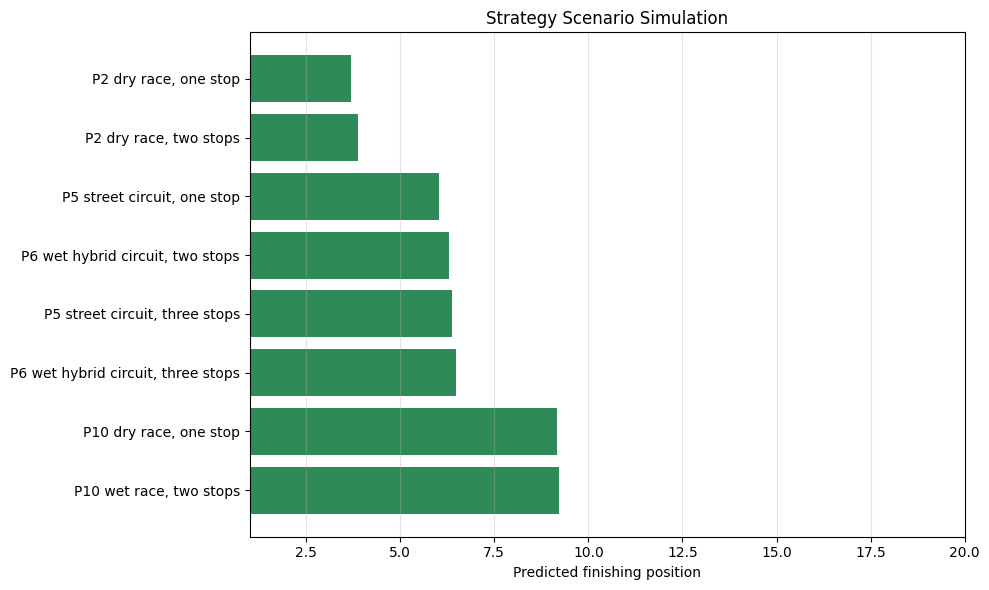

In [16]:
display(Image(filename=f"{RESULTS_DIR}/F1_Strategy_Scenarios.png"))


The saved output files appear in the `results/` folder, and the merged race table is stored in the `data/` folder.

## Three-source comparison and feature sources

This project uses three Formula 1 data sources. OpenF1 is the base driver-race table for qualifying position, finishing position, pit stop count, and driver information. FastF1 contributes weather variables such as rainfall and track temperature. Kaggle/Ergast metadata is used to engineer circuit type as street, permanent, or hybrid. The separate source-comparison table still checks that the qualifying-position relationship appears across OpenF1, FastF1, and Kaggle samples.


In [17]:
comparison_path = RESULTS_DIR / "source_comparison_summary.csv"
if comparison_path.exists():
    comparison_df = pd.read_csv(comparison_path)
    display(comparison_df)
else:
    print("Source comparison table is generated when running: python src/main.py --source all")


Source comparison table is generated when running: python src/main.py --source all
